In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# === CONFIGURAÇÕES ===
INPUT_CSV = "/home/pedro/UnB/FeatureExtraction/datasets/COVID_Dataset_331_RGB_splitted/Reports/final_report.csv"
OUTPUT_CSV = "/home/pedro/UnB/FeatureExtraction/datasets/COVID_Dataset_331_RGB_splitted/Reports/final_report_clean.csv"

In [5]:
# === CARREGAR CSV ===
df = pd.read_csv(INPUT_CSV)

In [6]:
# === REMOVER DUPLICADAS ===
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f"Removidas {before - after} linhas duplicadas.")

Removidas 60 linhas duplicadas.


In [7]:
# === SALVAR CSV LIMPO ===
df.to_csv(OUTPUT_CSV, index=False)
print(f"Arquivo limpo salvo em: {OUTPUT_CSV}")

Arquivo limpo salvo em: /home/pedro/UnB/FeatureExtraction/datasets/COVID_Dataset_331_RGB_splitted/Reports/final_report_clean.csv


In [9]:
## Top 5 por F1-Score
top5 = df.sort_values(by="Val_F1", ascending=False).head(5)
print("\nTop 5 classificadores por F1-Score:")
print(top5[["Arquivo Feature", "Classifier", "Val_F1", "Tempo Execucao (s)"]])


Top 5 classificadores por F1-Score:
            Arquivo Feature           Classifier    Val_F1  Tempo Execucao (s)
0  EfficientNetV2L_features                  SVM  0.905448           64.239592
2            VGG19_features                  SVM  0.905197         1115.074621
4         ResNet50_features                  SVM  0.899535          141.778344
6            VGG16_features                  SVM  0.898290         1123.270060
8  EfficientNetV2L_features  Logistic Regression  0.895960           17.886017


In [13]:
## Algoritmo mais rápido e mais lento
fastest = df.loc[df["Tempo Execucao (s)"].idxmin()]
slowest = df.loc[df["Tempo Execucao (s)"].idxmax()]
print(f"\nMais rápido: {fastest['Classifier']} ({fastest['Tempo Execucao (s)']:.2f}s)")
print(f"Mais lento: {slowest['Classifier']} ({slowest['Tempo Execucao (s)']:.2f}s)")


Mais rápido: Naive Bayes (0.41s)
Mais lento: LightGBM (2132.22s)


In [14]:
## Melhores por Feature Extractor
print("\nMelhor classificador por Feature Extractor:")
for feature, group in df.groupby("Arquivo Feature"):
    best = group.sort_values(by="Val_F1", ascending=False).iloc[0]
    print(f"{feature}: {best['Classifier']} - F1: {best['Val_F1']:.4f}")


Melhor classificador por Feature Extractor:
EfficientNetV2L_features: SVM - F1: 0.9054
InceptionV3_features: SVM - F1: 0.8754
ResNet50_features: SVM - F1: 0.8995
VGG16_features: SVM - F1: 0.8983
VGG19_features: SVM - F1: 0.9052


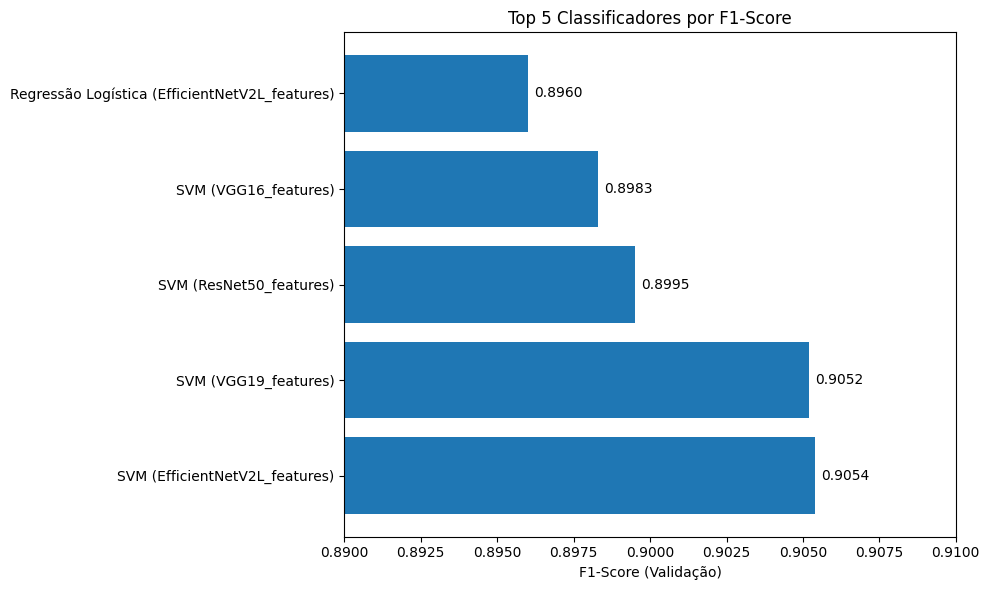

In [19]:
plt.figure(figsize=(10, 6))
bars = plt.barh(top5['Classificador'] + " (" + top5['Arquivo Feature'] + ")", top5['F1-Score (Val)'], color='tab:blue')
plt.xlabel('F1-Score (Validação)')
plt.xlim(0.89, 0.91)  # Dá um "zoom" no eixo X

# Anotação dos valores
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.0002, bar.get_y() + bar.get_height()/2, f"{width:.4f}", va='center')

plt.title('Top 5 Classificadores por F1-Score')
plt.tight_layout()
plt.savefig('top5_classificadores_zoom.png')
plt.show()

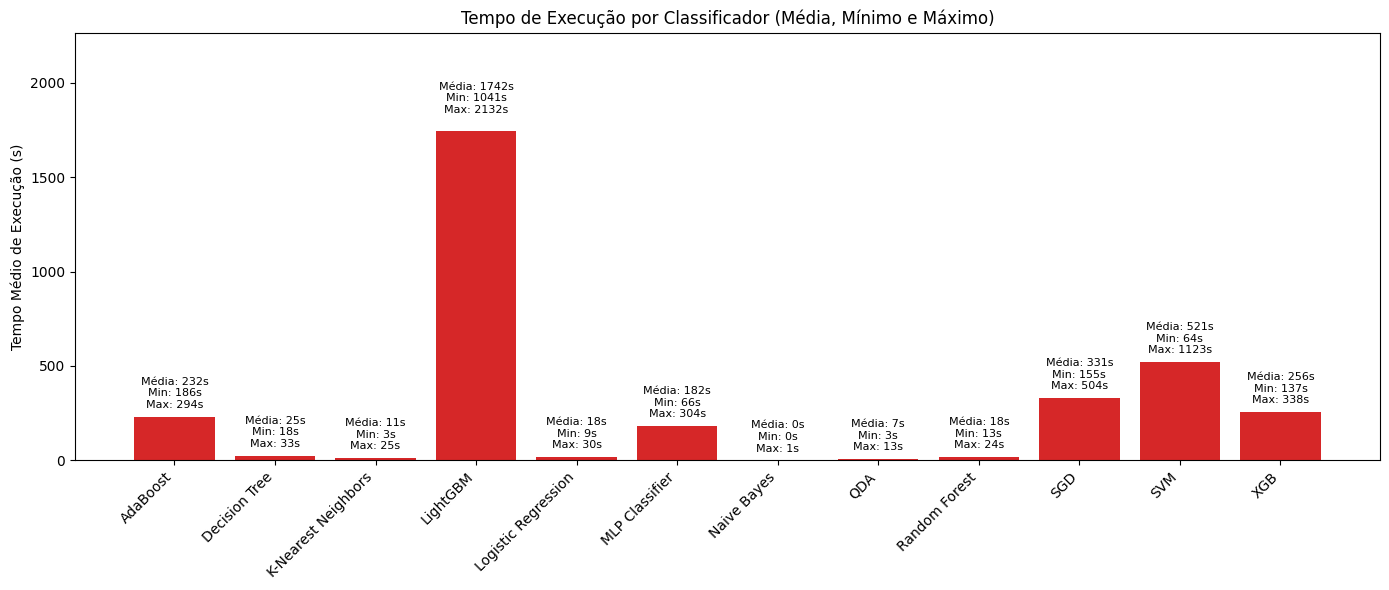

In [29]:
# Agrupa por classificador
tempo_grouped = df.groupby('Classifier')['Tempo Execucao (s)'].agg(['mean', 'min', 'max']).reset_index()

plt.figure(figsize=(14, 6))
bars = plt.bar(tempo_grouped['Classifier'], tempo_grouped['mean'], color='tab:red')

# Ajustar altura do gráfico
max_height = tempo_grouped['mean'].max()
plt.ylim(0, max_height * 1.3)  # deixa espaço pro texto

# Adicionar os textos (com ajuste para LightGBM)
for idx, row in tempo_grouped.iterrows():
    label = f"Média: {int(row['mean'])}s\nMin: {int(row['min'])}s\nMax: {int(row['max'])}s"
    if row['Classifier'] == 'LightGBM':
        y = row['mean'] + max_height * 0.05  # sobe bastante
    else:
        y = row['mean'] + max_height * 0.02  # menos espaço pros outros
    plt.text(idx, y, label, ha='center', va='bottom', fontsize=8)

plt.xticks(rotation=45, ha='right')
plt.ylabel('Tempo Médio de Execução (s)')
plt.title('Tempo de Execução por Classificador (Média, Mínimo e Máximo)')
plt.tight_layout()
plt.savefig('tempo_execucao_ajustado.png')
plt.show()

In [32]:
plt.figure(figsize=(10, 6))
plt.bar(df['Arquivo Feature'], df['Val_F1'], color='tab:green')
plt.xticks(rotation=20)
plt.ylabel('F1-Score (Validação)')
plt.title('Melhor Classificador por Arquitetura de Feature Extraction')
plt.tight_layout()
plt.savefig('melhor_por_extractor.png')
plt.close()

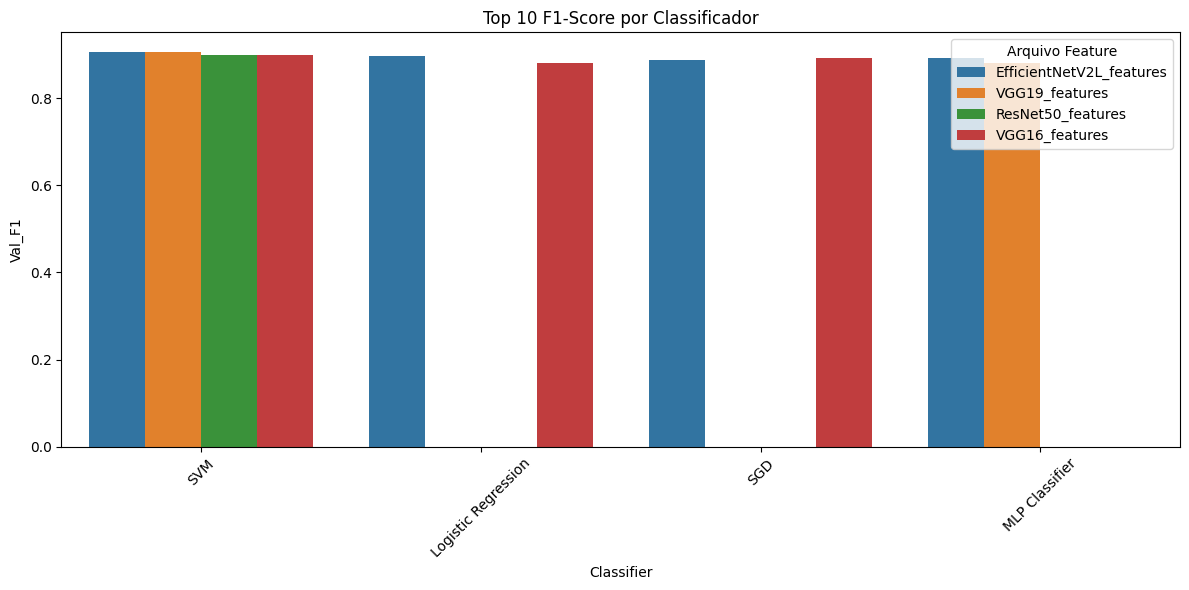

/tmp/ipykernel_10236/3132317831.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x="Classifier", y="Tempo Execucao (s)", ci=None)


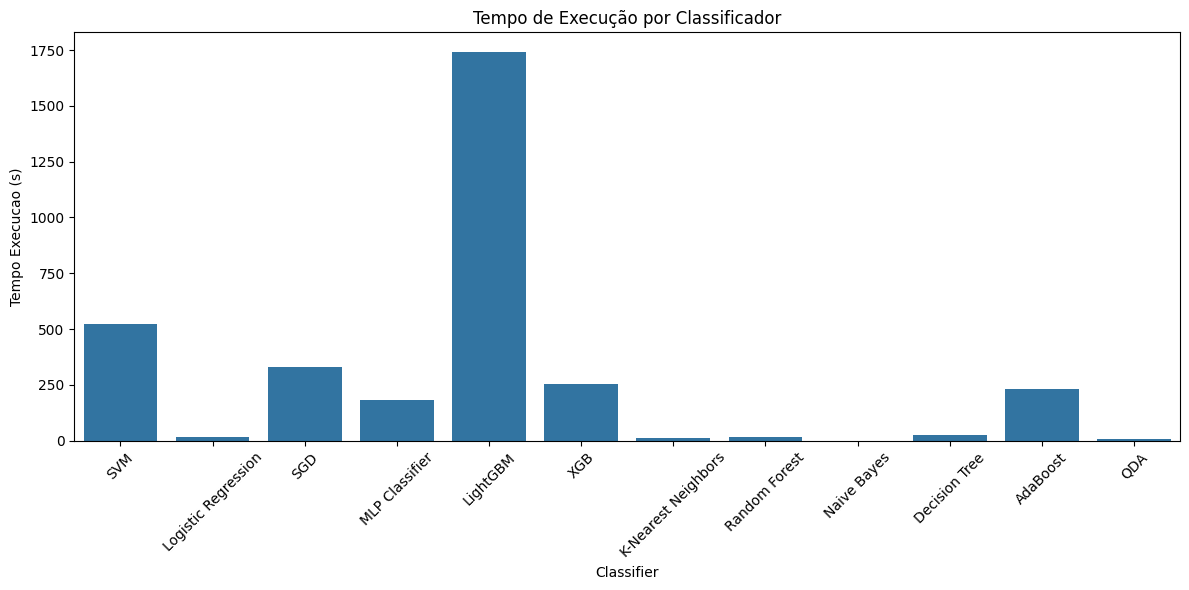

In [15]:
# === GRÁFICOS ===

plt.figure(figsize=(12, 6))
sns.barplot(data=df.sort_values(by="Val_F1", ascending=False)[:10], x="Classifier", y="Val_F1", hue="Arquivo Feature")
plt.title("Top 10 F1-Score por Classificador")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=df, x="Classifier", y="Tempo Execucao (s)", ci=None)
plt.title("Tempo de Execução por Classificador")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()